# Homework 1: Online Shoppers Intention
## 1. Постановка задачи

Цель работы — построить модель бинарной классификации, которая по характеристикам пользовательской сессии предсказывает, завершится ли сессия покупкой.

Целевая переменная — `Revenue`:

- `True` — сессия завершилась покупкой;
- `False` — покупка не была совершена.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Гипотезы до начала экспериментов

1. После подготовки признаков Logistic Regression покажет более высокий средний Average Precision, чем Decision Tree с параметрами по умолчанию. Критерий: разница не менее 0,01.

2. Ограничение сложности Decision Tree повысит Validation Average Precision минимум на 0,01 и уменьшит разрыв между train и validation минимум на 0,05.

3. Logistic Regression с L1-регуляризацией обнулит не менее 20% коэффициентов, а её Average Precision будет отличаться от L2 не более чем на 0,01.

4. Использование `class_weight="balanced"` увеличит Recall положительного класса Logistic Regression минимум на 0,10.

5. Добавление признака `AvgProductDuration` увеличит средний Average Precision минимум на 0,005, причём улучшение произойдёт минимум на четырёх из пяти фолдов.

6. Удаление признака `PageValues` снизит средний Average Precision минимум на 0,03.

Все гипотезы проверяются только на обучающей выборке с использованием одинаковых фолдов кросс-валидации. Финальная тестовая выборка не используется при выборе моделей и проверке гипотез.

## 3. Загрузка и первичная проверка данных

Загрузим датасет и проверим его размер, первые строки, типы признаков и наличие пропущенных значений.

In [2]:
df = pd.read_csv("data/online_shoppers_intention.csv")

#### Первые строки датасета

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


#### Размер и типы данных

In [4]:
print("Размер таблицы:", df.shape)
df.info()

Размер таблицы: (12330, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  

**Вывод.** Датасет содержит 12 330 пользовательских сессий и 18 столбцов, включая целевую переменную `Revenue`. В данных присутствуют числовые, категориальные и логические признаки. По результатам первичной проверки пропущенные значения отсутствуют.

### Проверка пропущенных значений и дубликатов

Проверим общее количество пропущенных значений и полностью повторяющихся строк.

In [5]:
missing_count = df.isna().sum().sum()
duplicates_count = df.duplicated().sum()

print("Количество пропущенных значений во всей таблице:", missing_count)
print("Количество полностью повторяющихся строк:", duplicates_count)

Количество пропущенных значений во всей таблице: 0
Количество полностью повторяющихся строк: 125


**Вывод.** Пропущенные значения в датасете отсутствуют. Обнаружено 125 полностью повторяющихся строк. Полные дубликаты будут удалены до разделения данных, чтобы одинаковые наблюдения не могли одновременно попасть в обучающую и тестовую выборки.

In [6]:
rows_before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
rows_after = df.shape[0]

print("Количество строк до удаления:", rows_before)
print("Количество строк после удаления:", rows_after)
print("Удалено строк:", rows_before - rows_after)

Количество строк до удаления: 12330
Количество строк после удаления: 12205
Удалено строк: 125


## 4. Разделение данных на обучающую и тестовую выборки

До проведения содержательного анализа отделим 20% данных для финальной оценки модели. Тестовая выборка не будет использоваться при EDA, подготовке признаков, подборе гиперпараметров и выборе модели.

Для сохранения соотношения классов используется стратифицированное разделение.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop(columns="Revenue")
y = df["Revenue"]

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (12205, 17)
Размер y: (12205,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9764, 17)
X_test: (2441, 17)
y_train: (9764,)
y_test: (2441,)


### Проверка соотношения классов после разделения

Проверим, сохранилась ли доля сессий с покупкой в обучающей и тестовой выборках благодаря использованию `stratify`.

In [10]:
full_positive_rate = y.mean()
train_positive_rate = y_train.mean()
test_positive_rate = y_test.mean()

print(f"Доля покупок во всех данных: {full_positive_rate:.2%}")
print(f"Доля покупок в train: {train_positive_rate:.2%}")
print(f"Доля покупок в test: {test_positive_rate:.2%}")

Доля покупок во всех данных: 15.63%
Доля покупок в train: 15.63%
Доля покупок в test: 15.65%


## 5. Исследовательский анализ данных — EDA

Исследовательский анализ проводится только на обучающей выборке. Сначала изучим распределение целевой переменной и оценим дисбаланс классов.

In [11]:
train_df = X_train.copy()

train_df["Revenue"] = y_train

print("Размер обучающей таблицы", train_df.shape)
train_df.head()

Размер обучающей таблицы (9764, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
7469,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,Nov,2,2,5,2,Returning_Visitor,False,True
11804,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,Dec,2,2,7,2,New_Visitor,False,True
3250,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,May,1,1,1,2,Returning_Visitor,False,False
204,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,Mar,2,2,7,2,New_Visitor,True,False
4392,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,May,4,2,2,13,Returning_Visitor,False,False


### Распределение целевой переменной

Посчитаем количество и долю сессий каждого класса в обучающей выборке.

In [12]:
class_counts = train_df["Revenue"].value_counts()
class_shares = train_df["Revenue"].value_counts(normalize=True)

print("Количество объектов каждого класса:")
print(class_counts)

print("Доля объектов каждого класса:")
print(class_shares)

Количество объектов каждого класса:
Revenue
False    8238
True     1526
Name: count, dtype: int64
Доля объектов каждого класса:
Revenue
False    0.843712
True     0.156288
Name: proportion, dtype: float64


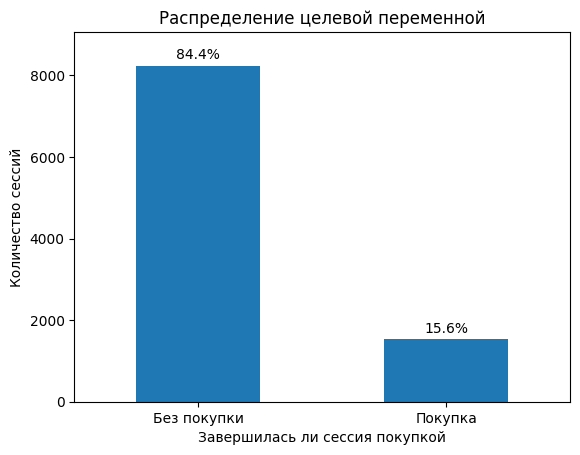

In [13]:
ax = class_counts.plot(kind="bar")

percent_labels = [
    f"{count / class_counts.sum():.1%}"
    for count in class_counts
]

ax.bar_label(
    ax.containers[0],
    labels=percent_labels,
    padding=3
)

plt.title("Распределение целевой переменной")
plt.xlabel("Завершилась ли сессия покупкой")
plt.ylabel("Количество сессий")
plt.xticks(
    ticks=[0, 1],
    labels=["Без покупки", "Покупка"],
    rotation=0
)

plt.ylim(0, class_counts.max() * 1.1)
plt.show()

**Вывод.** Целевая переменная несбалансирована: покупкой завершаются около 15,6% сессий, а около 84,4% сессий относятся к классу без покупки. Поэтому accuracy нельзя использовать как единственную метрику. Модель, которая всегда предсказывает отсутствие покупки, уже получила бы accuracy около 84,4%, но не обнаружила бы ни одной покупки. Для оценки моделей дополнительно будут использоваться Average Precision, ROC-AUC, Precision, Recall и F1.

### Группировка признаков по смыслу

Разделим признаки на числовые и категориальные. Некоторые категориальные признаки закодированы целыми числами, поэтому их тип `int64` не означает, что они являются количественными.

In [14]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

print("Количество числовых признаков:", len(numeric_features))
print("Количество категориальных признаков:", len(categorical_features))
print("Всего признаков:", len(numeric_features) + len(categorical_features))

Количество числовых признаков: 10
Количество категориальных признаков: 7
Всего признаков: 17


In [15]:
for column in categorical_features:
    print(f"{column}:")
    print(*train_df[column].unique(), sep=",")
    print()

Month:
Nov,Dec,May,Mar,Oct,Sep,Jul,Feb,Aug,June

OperatingSystems:
2,1,4,3,8,5,6,7

Browser:
2,1,5,8,10,4,6,7,3,13,11,12,9

Region:
5,7,1,2,3,6,4,8,9

TrafficType:
2,13,3,1,4,20,8,5,7,11,10,15,6,19,18,9,14,16,17

VisitorType:
Returning_Visitor,New_Visitor,Other

Weekend:
False,True



### Описательная статистика числовых признаков

Рассчитаем основные статистические характеристики числовых признаков: среднее, стандартное отклонение, минимальное и максимальное значения, а также квартили.

In [16]:
numeric_summary = train_df[numeric_features].describe()

numeric_summary

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,9764.000000,9764.000000,9764.000000,9764.000000,9764.000000,9764.000000,9764.000000,9764.000000,9764.000000,9764.000000
mean,2.342687,82.219938,0.510344,34.950623,32.101803,1207.264687,0.020296,0.041469,5.945606,0.062351
std,3.349268,179.502363,1.282728,143.828323,44.817312,1926.389159,0.045234,0.046145,18.860076,0.199959
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.466667,0.000000,0.014286,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,617.000000,0.002857,0.025000,0.000000,0.000000
75%,4.000000,94.725000,0.000000,0.000000,39.000000,1483.650000,0.016667,0.049242,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


**Вывод.** У ряда числовых признаков среднее значение значительно превышает медиану:

- `Administrative_Duration`: среднее — около 82 секунд, медиана — 9 секунд;
- `Informational_Duration`: среднее — около 35 секунд, медиана — 0 секунд;
- `ProductRelated_Duration`: среднее — около 1207 секунд, медиана — 617 секунд;
- `PageValues`: среднее — около 5,95, медиана — 0.

Максимальные значения также значительно превышают третьи квартили. Например, для `ProductRelated` третий квартиль равен 39, а максимальное значение — 705. Для `ProductRelated_Duration` третий квартиль составляет около 1484 секунд, а максимум превышает 63 тысячи секунд.

Это указывает на правую асимметрию распределений: большинство сессий имеют небольшие значения признаков, однако встречается небольшое число очень длинных или активных сессий. Такие значения пока нельзя автоматически считать ошибками, поскольку они могут соответствовать реальному поведению пользователей.

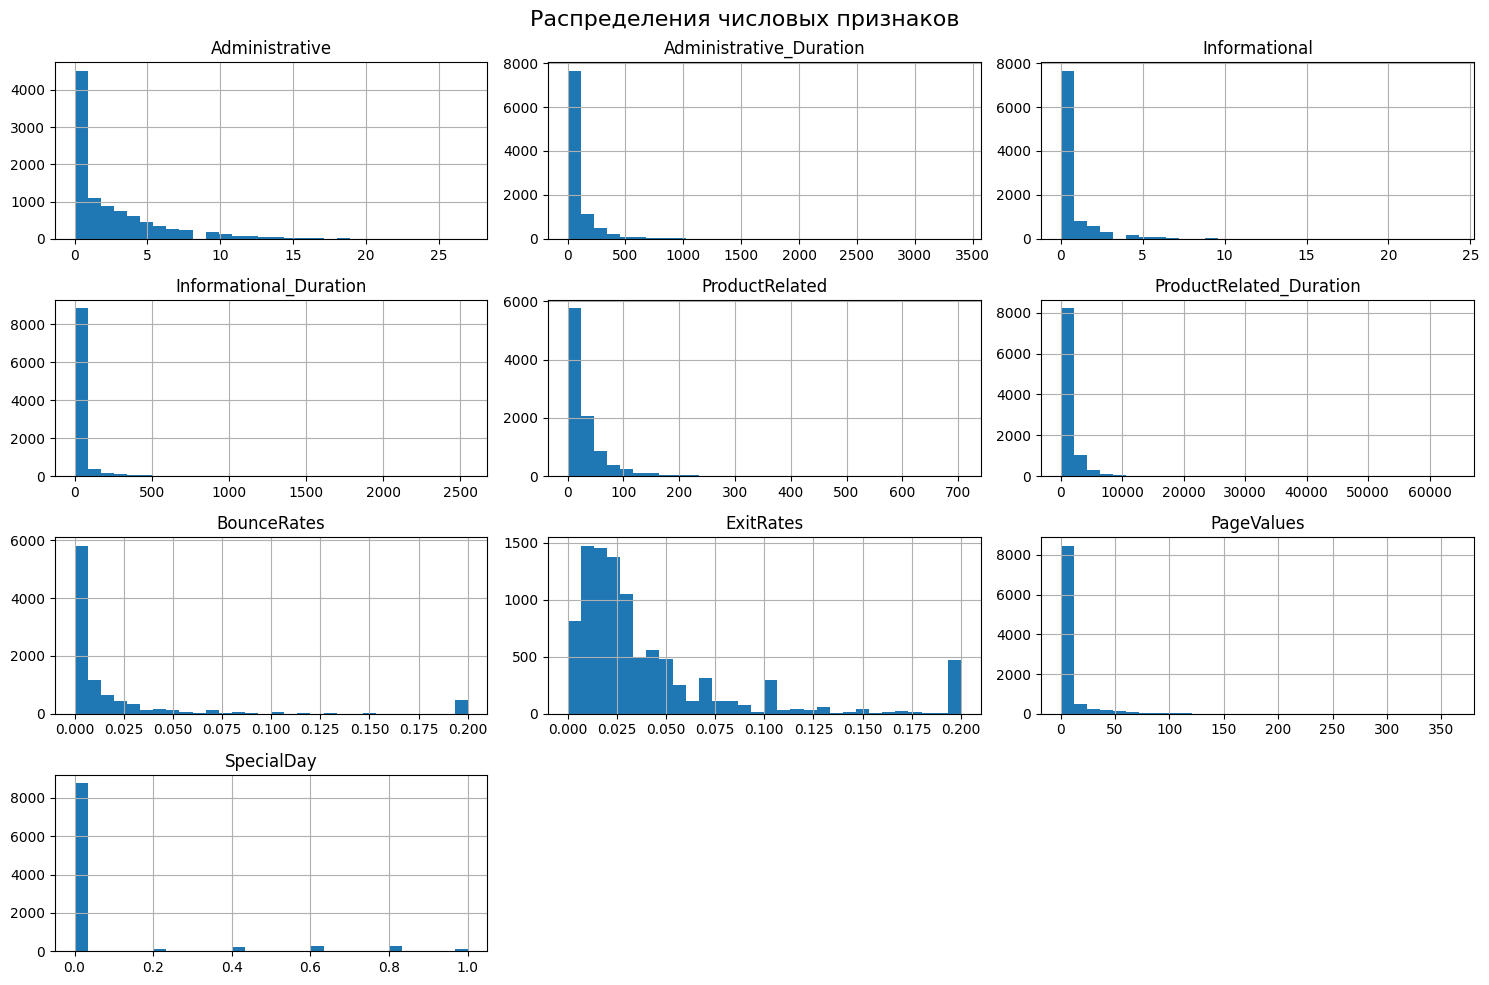

In [17]:
train_df[numeric_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle(
    "Распределения числовых признаков",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Вывод.** Распределения большинства числовых признаков имеют выраженную правую асимметрию и содержат большое количество нулевых значений. Это согласуется с результатами описательной статистики: средние значения часто превышают медианы, а максимумы значительно выше третьих квартилей.

### Доля нулевых значений

Для каждого числового признака рассчитаем долю сессий, в которых значение равно нулю.

In [18]:
zero_shares = (
    (train_df[numeric_features] == 0).mean().sort_values(ascending=False)
)

zero_shares_percent = (zero_shares * 100).round(1)

zero_shares_percent

SpecialDay                 89.7
Informational_Duration     80.4
Informational              78.4
PageValues                 77.6
Administrative_Duration    47.4
Administrative             46.3
BounceRates                45.3
ProductRelated_Duration     5.2
ExitRates                   0.7
ProductRelated              0.3
dtype: float64

**Вывод.** Числовые признаки заметно различаются по доле нулевых значений:

- `SpecialDay` равен нулю в 89,7% сессий;
- `Informational_Duration` — в 80,4%;
- `Informational` — в 78,4%;
- `PageValues` — в 77,6%;
- `Administrative_Duration` — в 47,4%;
- `Administrative` — в 46,3%.

При этом товарные страницы присутствуют почти во всех сессиях: `ProductRelated` равен нулю только в 0,3% случаев, а `ProductRelated_Duration` — в 5,2%.

Нулевые значения имеют содержательный смысл и не являются пропусками. Например, ноль в `Informational` означает, что пользователь не посещал информационные страницы. Поэтому такие значения не будут удаляться или автоматически заменяться.

### Корреляция числовых признаков с целевой переменной

Рассчитаем корреляции числовых признаков с `Revenue` на обучающей выборке. Категориальные признаки, представленные числовыми кодами, в этот расчёт не включаются, поскольку расстояние между их кодами не имеет количественного смысла.

In [19]:
correlation_columns = numeric_features + ["Revenue"]

correlation_matrix = train_df[correlation_columns].corr()

target_correlations = (
    correlation_matrix["Revenue"]
    .drop("Revenue")
    .sort_values()
)

target_correlations

ExitRates                 -0.204597
BounceRates               -0.144115
SpecialDay                -0.086536
Informational_Duration     0.065307
Administrative_Duration    0.079256
Informational              0.086463
Administrative             0.135084
ProductRelated_Duration    0.141933
ProductRelated             0.147667
PageValues                 0.488122
Name: Revenue, dtype: float64

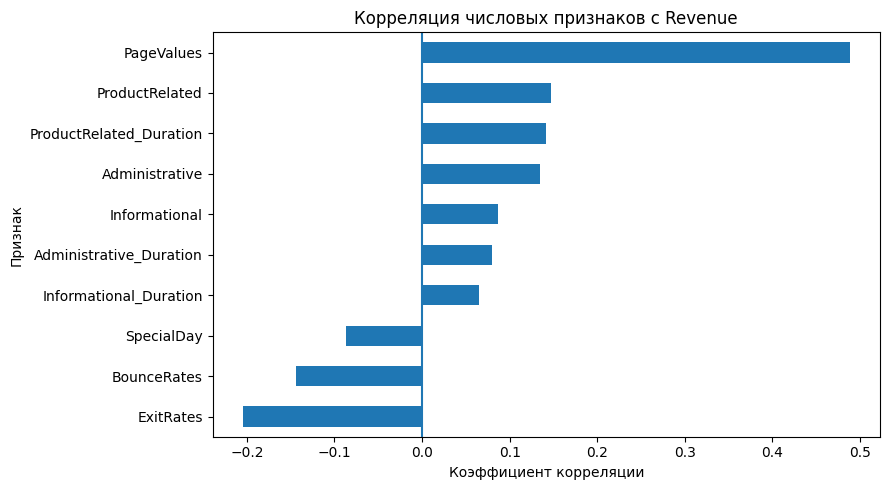

In [20]:
plt.figure(figsize=(9, 5))

target_correlations.plot(kind="barh")

plt.axvline(0)
plt.title("Корреляция числовых признаков с Revenue")
plt.xlabel("Коэффициент корреляции")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

**Вывод.** Наиболее сильная положительная линейная связь с фактом покупки наблюдается у признака `PageValues`: коэффициент корреляции составляет около 0,49. Это заметно больше, чем у остальных числовых признаков.

Умеренная положительная связь также наблюдается у:

- `ProductRelated` — около 0,15;
- `ProductRelated_Duration` — около 0,14;
- `Administrative` — около 0,14.

Наиболее выраженная отрицательная связь обнаружена у:

- `ExitRates` — около −0,20;
- `BounceRates` — около −0,14.

Это означает, что сессии с более высокими показателями выхода и отказов в среднем реже завершаются покупкой. Однако корреляция показывает только статистическую линейную связь и не доказывает причинно-следственное влияние признака на покупку.

Низкая корреляция также не означает, что признак бесполезен для модели: связь может быть нелинейной или проявляться только во взаимодействии с другими признаками.

### Корреляции между числовыми признаками

Построим корреляционную матрицу числовых признаков, чтобы найти признаки с сильной линейной связью. Наличие сильной корреляции не означает, что один из признаков обязательно нужно удалить, но может указывать на частичное дублирование информации.

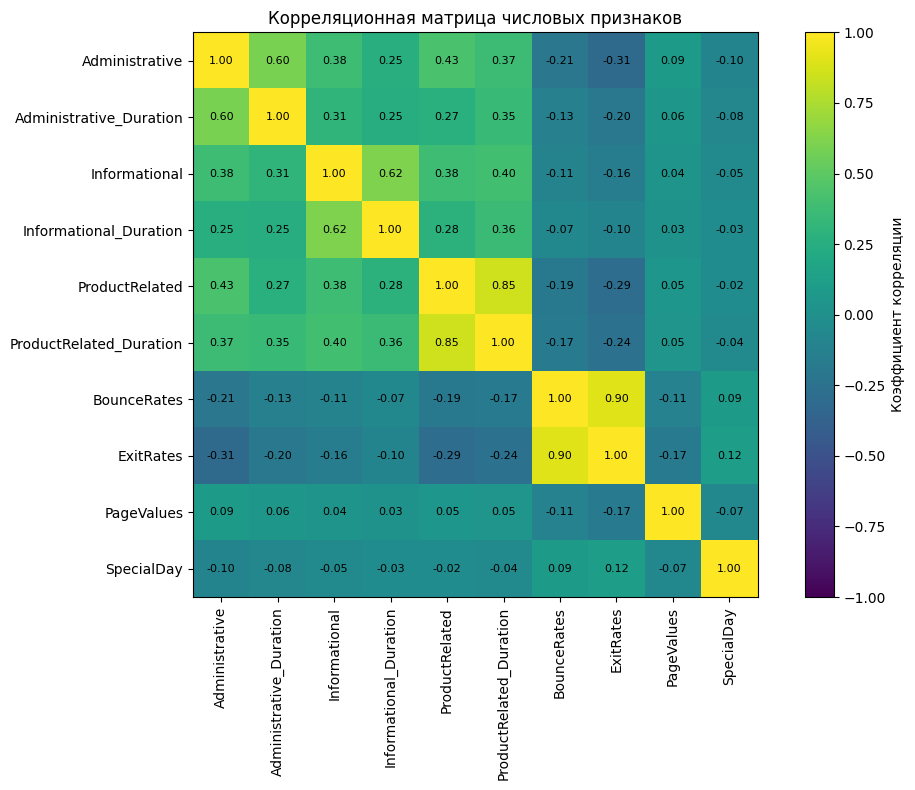

In [21]:
feature_correlation_matrix = train_df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(11, 8))

image = ax.imshow(
    feature_correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))

ax.set_xticklabels(numeric_features, rotation=90)
ax.set_yticklabels(numeric_features)

for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(
            j,
            i,
            f"{feature_correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(image, ax=ax, label="Коэффициент корреляции")
plt.title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

**Вывод.** Между некоторыми числовыми признаками обнаружена сильная линейная связь. Наибольшая корреляция наблюдается между `BounceRates` и `ExitRates` — около 0,90, а также между `ProductRelated` и `ProductRelated_Duration` — около 0,85.

Умеренная связь присутствует между количеством посещённых страниц и временем их просмотра: корреляция `Administrative` с `Administrative_Duration` составляет около 0,60, а `Informational` с `Informational_Duration` — около 0,62.

Такие связи могут указывать на частичное дублирование информации и мультиколлинеарность, что особенно важно для логистической регрессии. Однако на этапе EDA признаки удаляться не будут. Позже их полезность будет проверена с помощью кросс-валидации и отбора признаков.

### Итоги EDA

В датасете отсутствуют пропущенные значения, однако были обнаружены и удалены 125 полных дубликатов. Целевая переменная несбалансирована: положительный класс составляет около 15,6% наблюдений.

Числовые признаки имеют разные масштабы, большое количество нулевых значений и выраженную правую асимметрию. Некоторые признаки сильно коррелируют между собой: корреляция `BounceRates` и `ExitRates` составляет около 0,90, а `ProductRelated` и `ProductRelated_Duration` — около 0,85.

Наиболее сильная линейная связь с целевой переменной наблюдается у `PageValues`. Дальнейшая полезность признаков будет оцениваться не только по корреляциям, а с помощью моделей и кросс-валидации.

## 6. Подготовка признаков

Числовые признаки имеют разные масштабы, поэтому для них используется стандартизация. Категориальные признаки преобразуются с помощью one-hot кодирования.

Все преобразования обучаются только на обучающей выборке. Для тестовой выборки используется только метод `transform`.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## 7. Проверка гипотез

### Гипотеза 1. Logistic Regression покажет более высокое качество, чем базовое дерево решений

После подготовки признаков сравним `LogisticRegression` и `DecisionTreeClassifier` с параметрами по умолчанию. В качестве дополнительного baseline используется `DummyClassifier`.

Все модели оцениваются на одинаковых пяти фолдах стратифицированной кросс-валидации. Основная метрика — Average Precision.

**Критерий подтверждения:** средний Average Precision логистической регрессии превышает результат дерева решений минимум на 0,01.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

In [25]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(strategy="prior")
        )
    ]
)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "accuracy": "accuracy"
}

In [27]:
models = {
    "DummyClassifier": dummy_pipeline,
    "LogisticRegression": logreg_pipeline,
    "DecisionTree": tree_pipeline
}

cv_results = {}

for model_name, model in models.items():
    result = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results[model_name] = result

print("Кросс-валидация завершена")

Кросс-валидация завершена


In [28]:
results_rows = []

for model_name, result in cv_results.items():
    results_rows.append(
        {
            "Модель": model_name,
            "Train AP": result["train_average_precision"].mean(),
            "Validation AP": result["test_average_precision"].mean(),
            "ROC-AUC": result["test_roc_auc"].mean(),
            "Precision": result["test_precision"].mean(),
            "Recall": result["test_recall"].mean(),
            "F1": result["test_f1"].mean(),
            "Accuracy": result["test_accuracy"].mean()
        }
    )

baseline_results = pd.DataFrame(results_rows)

baseline_results = baseline_results.sort_values(
    by="Validation AP",
    ascending=False
).reset_index(drop=True)

baseline_results.round(3)

,Модель,Train AP,Validation AP,ROC-AUC,Precision,Recall,F1,Accuracy
0,LogisticRegression,0.650,0.636,0.889,0.744,0.372,0.496,0.882
1,DecisionTree,1.000,0.385,0.742,0.558,0.568,0.563,0.862
2,DummyClassifier,0.156,0.156,0.500,0.000,0.000,0.000,0.844


**Вывод по гипотезе 1.** `LogisticRegression` показала средний Validation Average Precision 0,636, тогда как результат базового `DecisionTreeClassifier` составил 0,385. Разница равна 0,251 и значительно превышает установленный критерий 0,01. Следовательно, гипотеза 1 подтвердилась.

У базового дерева Train Average Precision равен 1,000, а Validation Average Precision — 0,385. Это указывает на сильное переобучение.

`DummyClassifier` получил accuracy 0,844, но его Recall и F1 равны нулю. Модель всегда предсказывает наиболее частый класс и не обнаруживает ни одной покупки, поэтому высокая accuracy в данном случае не говорит о хорошем качестве классификации.

### Гипотеза 2. Ограничение сложности дерева уменьшит переобучение

Базовое дерево решений показало сильное переобучение: Train Average Precision равен 1,000, тогда как Validation Average Precision составляет 0,385.

Проверим, позволит ли подбор параметров `max_depth`, `min_samples_split` и `min_samples_leaf` повысить качество дерева на кросс-валидации и уменьшить разрыв между train и validation.

**Критерии подтверждения:**

- Validation Average Precision увеличивается минимум на 0,01;
- разрыв между Train Average Precision и Validation Average Precision уменьшается минимум на 0,05.

Для подбора параметров используется `GridSearchCV`. Финальная тестовая выборка в эксперименте не используется.

In [29]:
from sklearn.model_selection import GridSearchCV

tree_param_grid = {
    "model__max_depth": [3, 5, 7, 10],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

tree_grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

tree_grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(tree_grid_search.best_params_)

print(
    "Лучший Validation Average Precision:",
    round(tree_grid_search.best_score_, 3)
)

Лучшие параметры:
{'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
Лучший Validation Average Precision: 0.695


In [30]:
best_tree_index = tree_grid_search.best_index_

tuned_tree_train_ap = (
    tree_grid_search.cv_results_["mean_train_score"][best_tree_index]
)

tuned_tree_validation_ap = (
    tree_grid_search.cv_results_["mean_test_score"][best_tree_index]
)

base_tree_train_ap = baseline_results.loc[
    baseline_results["Модель"] == "DecisionTree",
    "Train AP"
].iloc[0]

base_tree_validation_ap = baseline_results.loc[
    baseline_results["Модель"] == "DecisionTree",
    "Validation AP"
].iloc[0]

tree_comparison = pd.DataFrame({
    "Модель": [
        "Базовое дерево",
        "Настроенное дерево"
    ],
    "Train AP": [
        base_tree_train_ap,
        tuned_tree_train_ap
    ],
    "Validation AP": [
        base_tree_validation_ap,
        tuned_tree_validation_ap
    ]
})

tree_comparison["Разрыв Train–Validation"] = (
    tree_comparison["Train AP"]
    - tree_comparison["Validation AP"]
)

tree_comparison.round(3)

,Модель,Train AP,Validation AP,Разрыв Train–Validation
0,Базовое дерево,1.000,0.385,0.615
1,Настроенное дерево,0.744,0.695,0.049


In [31]:
validation_improvement = (
    tuned_tree_validation_ap - base_tree_validation_ap
)

base_gap = base_tree_train_ap - base_tree_validation_ap
tuned_gap = tuned_tree_train_ap - tuned_tree_validation_ap

gap_reduction = base_gap - tuned_gap

print(
    "Улучшение Validation AP:",
    round(validation_improvement, 3)
)

print(
    "Разрыв базового дерева:",
    round(base_gap, 3)
)

print(
    "Разрыв настроенного дерева:",
    round(tuned_gap, 3)
)

print(
    "Уменьшение разрыва:",
    round(gap_reduction, 3)
)

if validation_improvement >= 0.01 and gap_reduction >= 0.05:
    print("Гипотеза 2 подтверждается.")
elif validation_improvement >= 0.01 or gap_reduction >= 0.05:
    print("Гипотеза 2 подтверждается частично.")
else:
    print("Гипотеза 2 не подтверждается.")

Улучшение Validation AP: 0.31
Разрыв базового дерева: 0.615
Разрыв настроенного дерева: 0.049
Уменьшение разрыва: 0.566
Гипотеза 2 подтверждается.


**Вывод по гипотезе 2.** После подбора гиперпараметров лучший результат показало дерево с `max_depth=5`, `min_samples_leaf=5` и `min_samples_split=2`.

Validation Average Precision увеличился с 0,385 до 0,695, то есть на 0,310. Одновременно разрыв между Train и Validation Average Precision уменьшился с 0,615 до 0,049 — на 0,566.

Оба заранее установленных критерия выполнены: качество на валидации увеличилось более чем на 0,01, а разрыв между train и validation уменьшился более чем на 0,05. Следовательно, гипотеза 2 подтвердилась. Ограничение сложности дерева значительно уменьшило переобучение и повысило его способность работать с новыми данными.

### Гипотеза 3. L1-регуляризация позволит отобрать признаки без существенного ухудшения качества

Сравним Logistic Regression с L1- и L2-регуляризацией.

L2-регуляризация уменьшает значения коэффициентов модели, но обычно не обнуляет их полностью. L1-регуляризация может сделать часть коэффициентов равными нулю, фактически исключив соответствующие признаки.

Для каждого варианта подберём параметр `C` на одинаковых фолдах кросс-валидации.

**Критерии подтверждения:**

- L1-регуляризация обнуляет не менее 20% коэффициентов;
- её Validation Average Precision отличается от результата L2 не более чем на 0,01.

Финальная тестовая выборка в эксперименте не используется.

In [32]:
l1_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

l2_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

logreg_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10]
}

l1_grid_search = GridSearchCV(
    estimator=l1_pipeline,
    param_grid=logreg_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

l2_grid_search = GridSearchCV(
    estimator=l2_pipeline,
    param_grid=logreg_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

l1_grid_search.fit(X_train, y_train)
l2_grid_search.fit(X_train, y_train)

print("Лучшее C для L1:", l1_grid_search.best_params_["model__C"])
print("Validation AP для L1:", round(l1_grid_search.best_score_, 3))

print("Лучшее C для L2:", l2_grid_search.best_params_["model__C"])
print("Validation AP для L2:", round(l2_grid_search.best_score_, 3))

Лучшее C для L1: 0.01
Validation AP для L1: 0.651
Лучшее C для L2: 0.01
Validation AP для L2: 0.641


In [33]:
best_l1_pipeline = l1_grid_search.best_estimator_

l1_model = best_l1_pipeline.named_steps["model"]
l1_coefficients = l1_model.coef_.ravel()

zero_coefficients_count = np.isclose(
    l1_coefficients,
    0,
    atol=1e-8
).sum()

total_coefficients_count = len(l1_coefficients)

zero_coefficients_share = (
    zero_coefficients_count / total_coefficients_count
)

ap_difference = abs(
    l1_grid_search.best_score_
    - l2_grid_search.best_score_
)

l1_l2_comparison = pd.DataFrame({
    "Регуляризация": ["L1", "L2"],
    "Лучшее C": [
        l1_grid_search.best_params_["model__C"],
        l2_grid_search.best_params_["model__C"]
    ],
    "Validation AP": [
        l1_grid_search.best_score_,
        l2_grid_search.best_score_
    ]
})

print("Всего коэффициентов:", total_coefficients_count)
print("Нулевых коэффициентов L1:", zero_coefficients_count)
print(
    "Доля нулевых коэффициентов:",
    f"{zero_coefficients_share:.1%}"
)
print(
    "Разница между L1 и L2 по AP:",
    round(ap_difference, 3)
)

l1_l2_comparison.round(3)

Всего коэффициентов: 74
Нулевых коэффициентов L1: 65
Доля нулевых коэффициентов: 87.8%
Разница между L1 и L2 по AP: 0.011


,Регуляризация,Лучшее C,Validation AP
0,L1,0.01,0.651
1,L2,0.01,0.641


In [34]:
if zero_coefficients_share >= 0.20 and ap_difference <= 0.01:
    print("Гипотеза 3 подтверждается.")
elif zero_coefficients_share >= 0.20 or ap_difference <= 0.01:
    print("Гипотеза 3 подтверждается частично.")
else:
    print("Гипотеза 3 не подтверждается.")

Гипотеза 3 подтверждается частично.


**Вывод по гипотезе 3.** Лучшее значение параметра `C` для обеих моделей равно 0,01. Logistic Regression с L1-регуляризацией показала Validation Average Precision 0,651, а модель с L2-регуляризацией — 0,641.

L1-регуляризация обнулила 65 из 74 коэффициентов, то есть 87,8%. Первый критерий гипотезы выполнен с большим запасом: модель фактически исключила значительную часть признаков.

Абсолютная разница между L1 и L2 по Average Precision составила 0,011, что на 0,001 превышает установленную границу 0,01. Поэтому строго по заранее установленным критериям гипотеза 3 подтвердилась частично.

При этом L1-регуляризация не ухудшила качество модели, а показала немного более высокий Average Precision. Следовательно, в данном эксперименте L1 позволила получить существенно более разреженную модель без потери качества.

### Гипотеза 4. Балансировка классов повысит Recall положительного класса

В обучающей выборке положительный класс составляет около 15,6% наблюдений. Из-за дисбаланса Logistic Regression может чаще отдавать предпочтение отрицательному классу.

Сравним две Logistic Regression с одинаковыми настройками:

- без балансировки классов;
- с `class_weight="balanced"`.

Параметр `class_weight="balanced"` автоматически назначает больший вес редкому положительному классу.

**Критерий подтверждения:** средний Recall положительного класса увеличивается минимум на 0,10.

Дополнительно сравним Precision, F1, Average Precision и ROC-AUC. Во всех случаях используется стандартный порог классификации 0,5.

In [35]:
best_l2_c = l2_grid_search.best_params_["model__C"]

logreg_without_balance = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=best_l2_c,
                class_weight=None,
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

logreg_with_balance = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=best_l2_c,
                class_weight="balanced",
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

In [36]:
balance_models = {
    "Без балансировки": logreg_without_balance,
    "class_weight='balanced'": logreg_with_balance
}

balance_cv_results = {}
balance_rows = []

for model_name, model in balance_models.items():
    result = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    balance_cv_results[model_name] = result

    balance_rows.append({
        "Модель": model_name,
        "Average Precision": result["test_average_precision"].mean(),
        "ROC-AUC": result["test_roc_auc"].mean(),
        "Precision": result["test_precision"].mean(),
        "Recall": result["test_recall"].mean(),
        "F1": result["test_f1"].mean(),
        "Accuracy": result["test_accuracy"].mean()
    })

balance_comparison = pd.DataFrame(balance_rows)

balance_comparison.round(3)

,Модель,Average Precision,ROC-AUC,Precision,Recall,F1,Accuracy
0,Без балансировки,0.641,0.894,0.757,0.330,0.459,0.879
1,class_weight='balanced',0.643,0.899,0.528,0.746,0.618,0.856


In [37]:
recall_without_balance = balance_comparison.loc[
    balance_comparison["Модель"] == "Без балансировки",
    "Recall"
].iloc[0]

recall_with_balance = balance_comparison.loc[
    balance_comparison["Модель"] == "class_weight='balanced'",
    "Recall"
].iloc[0]

recall_improvement = (
    recall_with_balance - recall_without_balance
)

print(
    "Recall без балансировки:",
    round(recall_without_balance, 3)
)

print(
    "Recall с балансировкой:",
    round(recall_with_balance, 3)
)

print(
    "Увеличение Recall:",
    round(recall_improvement, 3)
)

if recall_improvement >= 0.10:
    print("Гипотеза 4 подтверждается.")
else:
    print("Гипотеза 4 не подтверждается.")

Recall без балансировки: 0.33
Recall с балансировкой: 0.746
Увеличение Recall: 0.416
Гипотеза 4 подтверждается.


**Вывод по гипотезе 4.** Использование `class_weight="balanced"` увеличило средний Recall положительного класса с 0,330 до 0,746. Прирост составил 0,416, что значительно превышает установленный критерий 0,10. Следовательно, гипотеза 4 подтвердилась.

Балансировка также увеличила F1 с 0,459 до 0,618, при этом Average Precision практически не изменился: 0,641 без балансировки и 0,643 с балансировкой.

Одновременно Precision снизился с 0,757 до 0,528. Это означает, что модель стала находить значительно больше сессий с покупкой, но также чаще ошибочно предсказывать покупку для отрицательного класса. Таким образом, балансировка изменила компромисс между Precision и Recall.

### Гипотеза 5. Среднее время просмотра товарной страницы улучшит Logistic Regression

Создадим новый признак:

`AvgProductDuration = ProductRelated_Duration / ProductRelated`

Он показывает среднюю продолжительность просмотра одной товарной страницы. В строках, где пользователь не посетил ни одной товарной страницы, значение нового признака будет равно нулю.

Сравним две одинаковые Logistic Regression:

- только с исходными признаками;
- с добавленным `AvgProductDuration`.

Обе модели оцениваются на одинаковых фолдах кросс-валидации.

**Критерии подтверждения:**

- средний Average Precision увеличивается минимум на 0,005;
- улучшение наблюдается минимум на 4 из 5 фолдов.

Финальная тестовая выборка в эксперименте не используется.

In [38]:
X_train_with_avg = X_train.copy()

X_train_with_avg["AvgProductDuration"] = np.where(
    X_train_with_avg["ProductRelated"] > 0,
    X_train_with_avg["ProductRelated_Duration"]
    / X_train_with_avg["ProductRelated"],
    0
)

X_train_with_avg[
    [
        "ProductRelated",
        "ProductRelated_Duration",
        "AvgProductDuration"
    ]
].head()

,ProductRelated,ProductRelated_Duration,AvgProductDuration
7469,42,1052.400000,25.057143
11804,30,901.288889,30.042963
3250,13,421.166667,32.397436
204,5,558.500000,111.700000
4392,16,1599.266667,99.954167


In [39]:
numeric_features_with_avg = (
    numeric_features + ["AvgProductDuration"]
)

preprocessor_with_avg = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features_with_avg
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [40]:
logreg_without_avg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=best_l2_c,
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

logreg_with_avg = Pipeline(
    steps=[
        ("preprocessor", preprocessor_with_avg),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=best_l2_c,
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

In [41]:
without_avg_result = cross_validate(
    estimator=logreg_without_avg,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

with_avg_result = cross_validate(
    estimator=logreg_with_avg,
    X=X_train_with_avg,
    y=y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

without_avg_scores = without_avg_result["test_score"]
with_avg_scores = with_avg_result["test_score"]

fold_improvements = with_avg_scores - without_avg_scores

avg_feature_comparison = pd.DataFrame({
    "Фолд": range(1, 6),
    "AP без нового признака": without_avg_scores,
    "AP с новым признаком": with_avg_scores,
    "Изменение AP": fold_improvements
})

avg_feature_comparison.round(3)

,Фолд,AP без нового признака,AP с новым признаком,Изменение AP
0,1,0.659,0.660,0.000
1,2,0.598,0.598,0.000
2,3,0.637,0.637,0.000
3,4,0.654,0.654,-0.000
4,5,0.656,0.654,-0.002


In [42]:
mean_ap_without_avg = without_avg_scores.mean()
mean_ap_with_avg = with_avg_scores.mean()

mean_ap_improvement = (
    mean_ap_with_avg - mean_ap_without_avg
)

improved_folds_count = (
    fold_improvements > 0
).sum()

print(
    "Средний AP без нового признака:",
    round(mean_ap_without_avg, 3)
)

print(
    "Средний AP с новым признаком:",
    round(mean_ap_with_avg, 3)
)

print(
    "Изменение среднего AP:",
    round(mean_ap_improvement, 3)
)

print(
    "Количество фолдов с улучшением:",
    improved_folds_count,
    "из 5"
)

if mean_ap_improvement >= 0.005 and improved_folds_count >= 4:
    print("Гипотеза 5 подтверждается.")
elif mean_ap_improvement >= 0.005 or improved_folds_count >= 4:
    print("Гипотеза 5 подтверждается частично.")
else:
    print("Гипотеза 5 не подтверждается.")

Средний AP без нового признака: 0.641
Средний AP с новым признаком: 0.641
Изменение среднего AP: -0.0
Количество фолдов с улучшением: 3 из 5
Гипотеза 5 не подтверждается.


**Вывод по гипотезе 5.** Средний Average Precision модели без нового признака составил 0,641. После добавления `AvgProductDuration` результат также составил около 0,641.

Небольшое улучшение наблюдалось только на 3 из 5 фолдов, а установленный критерий требовал улучшения минимум на 4 фолдах и увеличения среднего Average Precision не менее чем на 0,005. Следовательно, гипотеза 5 не подтвердилась.

Вероятно, новый признак не добавил модели существенной информации, поскольку исходные признаки `ProductRelated` и `ProductRelated_Duration` уже присутствуют в данных. Отсутствие улучшения не означает, что признак рассчитан неправильно: эксперимент показал, что для выбранной Logistic Regression он оказался избыточным.

### Гипотеза 6. Удаление PageValues заметно ухудшит качество модели

В ходе EDA признак `PageValues` показал наиболее сильную линейную связь с целевой переменной: коэффициент корреляции с `Revenue` составил около 0,49.

Проведём ablation-эксперимент: обучим две одинаковые Logistic Regression на одинаковых фолдах:

- со всеми исходными признаками;
- без признака `PageValues`.

Все параметры модели останутся одинаковыми. Это позволит оценить, насколько качество модели зависит именно от `PageValues`.

**Критерий подтверждения:** после удаления `PageValues` средний Average Precision уменьшается минимум на 0,03.

Финальная тестовая выборка в эксперименте не используется.

In [43]:
X_train_without_pagevalues = X_train.drop(
    columns="PageValues"
)

numeric_features_without_pagevalues = [
    feature
    for feature in numeric_features
    if feature != "PageValues"
]

preprocessor_without_pagevalues = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features_without_pagevalues
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [44]:
logreg_all_features = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=best_l2_c,
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

logreg_without_pagevalues = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_without_pagevalues
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=best_l2_c,
                max_iter=3000,
                random_state=42
            )
        )
    ]
)

In [45]:
all_features_result = cross_validate(
    estimator=logreg_all_features,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

without_pagevalues_result = cross_validate(
    estimator=logreg_without_pagevalues,
    X=X_train_without_pagevalues,
    y=y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

all_features_scores = all_features_result["test_score"]
without_pagevalues_scores = without_pagevalues_result["test_score"]

pagevalues_comparison = pd.DataFrame({
    "Фолд": range(1, 6),
    "AP со всеми признаками": all_features_scores,
    "AP без PageValues": without_pagevalues_scores,
    "Снижение AP": (
        all_features_scores - without_pagevalues_scores
    )
})

pagevalues_comparison.round(3)

,Фолд,AP со всеми признаками,AP без PageValues,Снижение AP
0,1,0.659,0.312,0.347
1,2,0.598,0.275,0.323
2,3,0.637,0.357,0.280
3,4,0.654,0.327,0.327
4,5,0.656,0.332,0.324


In [46]:
mean_ap_all_features = all_features_scores.mean()
mean_ap_without_pagevalues = (
    without_pagevalues_scores.mean()
)

pagevalues_ap_drop = (
    mean_ap_all_features
    - mean_ap_without_pagevalues
)

print(
    "Средний AP со всеми признаками:",
    round(mean_ap_all_features, 3)
)

print(
    "Средний AP без PageValues:",
    round(mean_ap_without_pagevalues, 3)
)

print(
    "Снижение среднего AP:",
    round(pagevalues_ap_drop, 3)
)

if pagevalues_ap_drop >= 0.03:
    print("Гипотеза 6 подтверждается.")
else:
    print("Гипотеза 6 не подтверждается.")

Средний AP со всеми признаками: 0.641
Средний AP без PageValues: 0.321
Снижение среднего AP: 0.32
Гипотеза 6 подтверждается.


**Вывод по гипотезе 6.** После удаления признака `PageValues` средний Average Precision логистической регрессии снизился с 0,641 до 0,321. Ухудшение составило 0,320, что значительно превышает установленный критерий 0,03. Следовательно, гипотеза 6 подтвердилась.

Снижение наблюдается на всех пяти фолдах кросс-валидации. Это показывает, что `PageValues` содержит важную для классификации информацию и существенно влияет на качество модели. При этом высокая полезность признака не означает, что он является причиной покупки.

## 8. Выбор финальной модели

Лучший средний Average Precision на кросс-валидации показало настроенное дерево решений — 0,695.

Его параметры:

- `max_depth=5`;
- `min_samples_leaf=5`;
- `min_samples_split=2`.

Настроенное дерево также имеет небольшой разрыв между Train и Validation Average Precision — 0,049. Поэтому оно выбирается в качестве финальной модели.

До этого момента тестовая выборка не использовалась для выбора модели, подбора гиперпараметров или проверки гипотез. Далее она используется один раз для окончательной оценки.

In [47]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [48]:
final_model = tree_grid_search.best_estimator_

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame({
    "Метрика": [
        "Average Precision",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1",
        "Accuracy"
    ],
    "Значение": [
        average_precision_score(y_test, y_test_proba),
        roc_auc_score(y_test, y_test_proba),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        accuracy_score(y_test, y_test_pred)
    ]
})

test_metrics.round(3)

,Метрика,Значение
0,Average Precision,0.693
1,ROC-AUC,0.925
2,Precision,0.706
3,Recall,0.641
4,F1,0.672
5,Accuracy,0.902


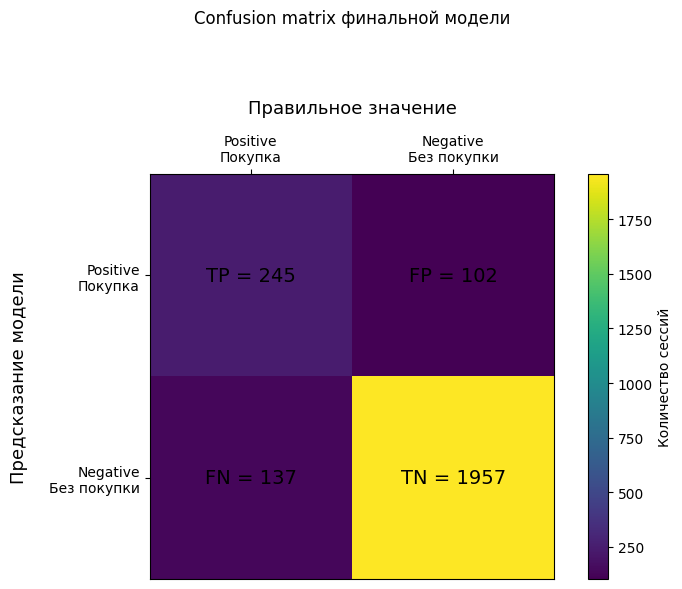

In [49]:
cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

custom_cm = np.array([
    [tp, fp],
    [fn, tn]
])

cell_names = np.array([
    ["TP", "FP"],
    ["FN", "TN"]
])

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(custom_cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Positive\nПокупка",
    "Negative\nБез покупки"
])

ax.set_yticklabels([
    "Positive\nПокупка",
    "Negative\nБез покупки"
])

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_xlabel(
    "Правильное значение",
    fontsize=13,
    labelpad=15
)

ax.set_ylabel(
    "Предсказание модели",
    fontsize=13,
    labelpad=15
)

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            f"{cell_names[row, column]} = {custom_cm[row, column]}",
            ha="center",
            va="center",
            fontsize=14
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Количество сессий")

plt.title(
    "Confusion matrix финальной модели",
    pad=55
)

plt.tight_layout()
plt.show()

In [50]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Без покупки", "Покупка"],
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Без покупки      0.935     0.950     0.942      2059
     Покупка      0.706     0.641     0.672       382

    accuracy                          0.902      2441
   macro avg      0.820     0.796     0.807      2441
weighted avg      0.899     0.902     0.900      2441



### Вывод по финальной оценке

На финальной тестовой выборке настроенное дерево решений показало следующие результаты:

- Average Precision — 0,693;
- ROC-AUC — 0,925;
- Precision положительного класса — 0,706;
- Recall положительного класса — 0,641;
- F1 положительного класса — 0,672;
- Accuracy — 0,902.

Значение Average Precision на тестовой выборке близко к результату кросс-валидации 0,695. Это указывает на то, что оценка качества модели на обучающей выборке была достаточно устойчивой.

Из 382 сессий, завершившихся покупкой, модель правильно обнаружила 245 и пропустила 137. Среди 347 сессий, для которых модель предсказала покупку, 245 действительно завершились покупкой, а 102 прогноза оказались ошибочными.

Несмотря на высокую Accuracy, основное внимание уделяется Average Precision, Precision, Recall и F1, поскольку положительный класс составляет только около 15,6% наблюдений.

## 9. Итоги проверки гипотез

### Гипотеза 1

Logistic Regression должна была превзойти базовое дерево решений по Average Precision минимум на 0,01.

Гипотеза подтвердилась. Средний Validation Average Precision логистической регрессии составил 0,636, а базового дерева — 0,385. Разница равна 0,251.

### Гипотеза 2

Ограничение сложности дерева должно было повысить Validation Average Precision и уменьшить переобучение.

Гипотеза подтвердилась. После подбора параметров Validation Average Precision увеличился с 0,385 до 0,695, а разрыв между train и validation уменьшился с 0,615 до 0,049.

### Гипотеза 3

L1-регуляризация должна была обнулить не менее 20% коэффициентов без отличия от L2 по Average Precision более чем на 0,01.

Гипотеза подтвердилась частично. L1 обнулила 65 из 74 коэффициентов, то есть 87,8%. При этом разница между L1 и L2 по Average Precision составила 0,011, что на 0,001 превышает установленную границу. L1 не ухудшила качество и показала результат 0,651 против 0,641 у L2.

### Гипотеза 4

Использование `class_weight="balanced"` должно было увеличить Recall положительного класса минимум на 0,10.

Гипотеза подтвердилась. Recall увеличился с 0,330 до 0,746, то есть на 0,416. Одновременно Precision снизился с 0,757 до 0,528, что демонстрирует компромисс между Precision и Recall.

### Гипотеза 5

Добавление `AvgProductDuration` должно было повысить средний Average Precision минимум на 0,005 и дать улучшение минимум на четырёх из пяти фолдов.

Гипотеза не подтвердилась. Средний Average Precision практически не изменился и остался около 0,641, а улучшение наблюдалось только на трёх из пяти фолдов.

### Гипотеза 6

Удаление `PageValues` должно было снизить средний Average Precision минимум на 0,03.

Гипотеза подтвердилась. После удаления `PageValues` средний Average Precision снизился с 0,641 до 0,321, то есть на 0,320.

## 10. Общий вывод

В работе была решена задача бинарной классификации пользовательских сессий интернет-магазина. Целевая переменная `Revenue` показывает, завершилась ли сессия покупкой.

Для предотвращения утечки финальная тестовая выборка была отделена до проведения EDA и не использовалась при подготовке данных, проверке гипотез, подборе гиперпараметров и выборе модели. Преобразования признаков выполнялись внутри `Pipeline`, а модели сравнивались на одинаковых фолдах стратифицированной кросс-валидации.

Базовое дерево решений сильно переобучилось, однако ограничение его сложности увеличило Validation Average Precision с 0,385 до 0,695. Лучшей моделью стало дерево с `max_depth=5`, `min_samples_leaf=5` и `min_samples_split=2`.

На финальной тестовой выборке модель получила Average Precision 0,693 и ROC-AUC 0,925. Результат на test оказался близок к результату кросс-валидации, что говорит об устойчивости полученной оценки.

Эксперименты также показали, что L1-регуляризация позволяет получить разреженную логистическую регрессию, балансировка классов значительно повышает Recall, а признак `PageValues` играет важную роль в качестве моделей. Созданный признак `AvgProductDuration` дополнительной пользы не дал.

Полученные зависимости являются статистическими и не доказывают причинно-следственное влияние признаков на совершение покупки.